C:\Users\Felix\AppData\Local\Temp\ipykernel_14884\2861613781.py:40: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  out[row, column] = scipy.stats.kurtosis(arr[0:row, column], fisher = False, nan_policy = "propagate")


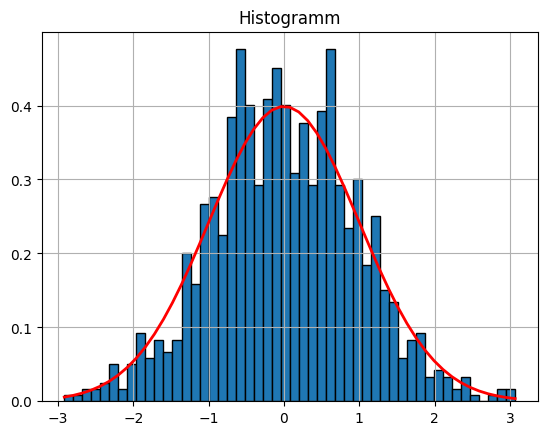

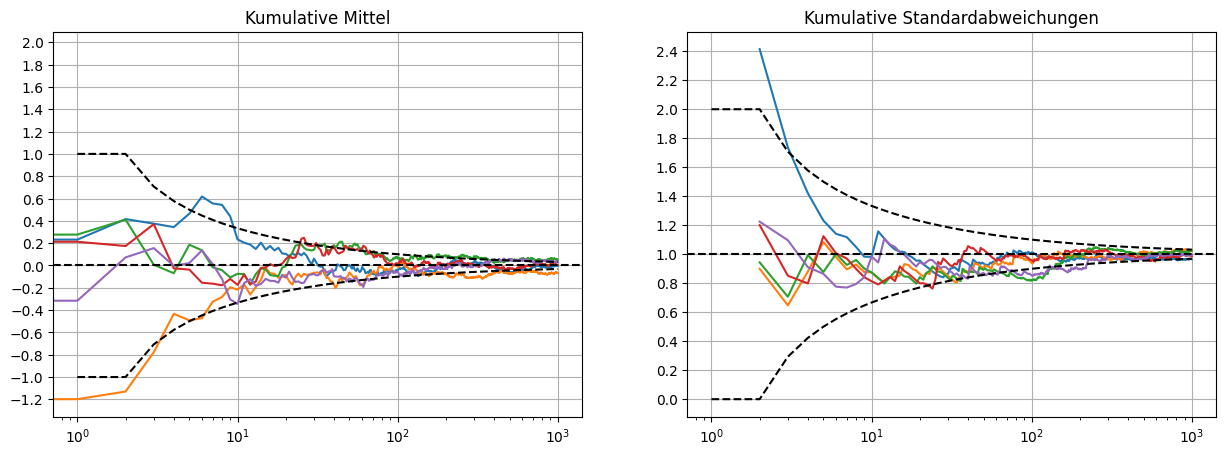

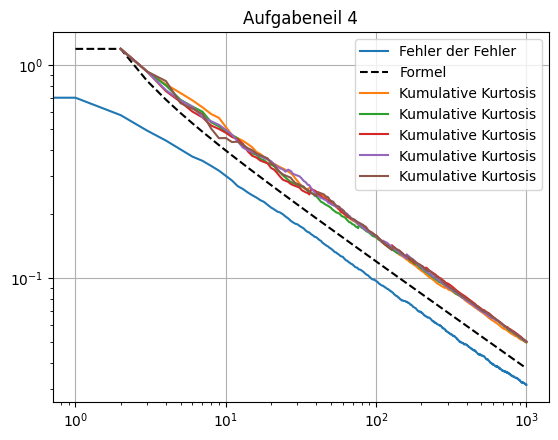

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

#Konstanten
MY = 0
SIGMA = 1
STICHPROBEN = 1000
REALISIERUNGEN = 1000

#Matrix mit zufälligen Werten erstellen (Spalten = Realisierungen)
X = np.random.normal(loc = MY , scale = SIGMA, size = (STICHPROBEN, REALISIERUNGEN))

#Vektor zum Vergleich
Y = np.zeros(STICHPROBEN)
Y[0] = -1
Y[1] = SIGMA
Y[2:] = SIGMA / np.sqrt(np.arange(2, STICHPROBEN)-1)


#Kumulative Funktionen
def cummean(arr):
    sum = np.cumsum(arr, axis = 0)
    count = np.arange(1,len(arr) + 1)
    count2d = np.transpose(np.repeat([count], len(arr[0]), axis = 0))
    return sum / count2d


def cumstd(arr):
    out = np.zeros((len(arr), len(arr[0])))
    for column in range(len(arr[0])):
        for i in range(0,len(arr)):
             out[i, column] = np.std(arr[0:i, column], ddof = 1)
    return out

def cumcort(arr, NumOfCols):
    out = np.zeros((STICHPROBEN, NumOfCols))
    for column in range(NumOfCols):
        for row in range(STICHPROBEN):
                out[row, column] = scipy.stats.kurtosis(arr[0:row, column], fisher = False, nan_policy = "propagate")
    return out


#Histogramm
fig, ax1 = plt.subplots(1,1)
ax1.grid(True)
hist, bins, ignored = plt.hist(X[:,0], bins = 50, edgecolor = "black", density = True)
ax1.plot(bins, 1/(1 * np.sqrt(2 * np.pi)) *np.exp( - (bins - 0)**2 / (2 * 1**2) ),linewidth=2, color='r')
plt.title("Histogramm")


fig , (ax2,ax3) = plt.subplots(1,2, figsize = (15,5))

#Kumulative Mittel
values = cummean(X)

ax2.semilogx(np.arange(0, STICHPROBEN, step = 1), values[:,0:5])
ax2.set_title("Kumulative Mittel")

ax2.plot(np.arange(1,STICHPROBEN, step = 1), MY + Y[1:], color = "black", linestyle = "--")
ax2.plot(np.arange(1,STICHPROBEN, step = 1), MY - Y[1:], color = "black", linestyle = "--")

ax2.axhline(0, color = "black", linestyle = "--")
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax2.grid(True)

#Kumulative Standardabweichungen
values = cumstd(X)

ax3.semilogx(np.arange(0, STICHPROBEN, step = 1), values[:,0:5])
ax3.set_title("Kumulative Standardabweichungen")

ax3.plot(np.arange(1,STICHPROBEN, step = 1), SIGMA + Y[1:], color = "black", linestyle = "--")
ax3.plot(np.arange(1,STICHPROBEN, step = 1), SIGMA - Y[1:], color = "black", linestyle = "--")

plt.axhline(1, color = "black", linestyle = "--")
ax3.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax3.grid(True)


fig, ax4 = plt.subplots(1,1)

#Fehler der Fehler
values = cummean(X)
ax4.loglog(np.arange(0, STICHPROBEN), np.std(values, axis = 1, ddof = 1), label = "Fehler der Fehler")
ax4.loglog(np.arange(1,STICHPROBEN), np.power(2,1/4)*Y[1:], "--", color = "black", label = "Formel")
ax4.plot(np.arange(0,STICHPROBEN), np.power(2*cumcort(X,5)[:,0:5], 1/4)*np.transpose(np.repeat([Y], 5, axis = 0)), label = "Kumulative Kurtosis")
    #Skaliere die kumulative Kurtosis mit Y damit es funktioniert
ax4.legend()
ax4.set_title("Aufgabenteil 4")
#ax4.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax4.grid(True)
